In [1]:
%load_ext autoreload
%autoreload 2

# DC4 Positron Goal 2: Galactic 511 keV Disk Scale Height
**Objective**

This notebook addresses the second DC4 positron goal using the 509--513 keV line data:

2. Determine the scale height of the Galactic 511 keV disk and prepare its comparison with the $^{26}$ Al distribution.

## Setup

In [2]:
# Set the repository root so local workflow modules can be imported.
from pathlib import Path
import sys

working_dir = Path.cwd()
repo_root = (
    working_dir.parent
    if working_dir.name == "notebooks"
    else working_dir
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

### Imports

In [3]:
import sys

import numpy as np

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.ExtendedSourceResponse import ExtendedSourceResponse
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLExtendedSourceResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.statistics import PoissonLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from histpy import Histogram
import astropy.units as u
from astropy.coordinates import SkyCoord
from mhealpy import HealpixMap, HealpixBase
from astromodels import (
    Asymm_Gaussian_on_sphere,
    Gaussian,
    Gaussian_on_sphere,
    LinearPolarization,
    PointSource, 
    ExtendedSource,
    Model,
)
from threeML import DataList, JointLikelihood


import matplotlib.pyplot as plt
%matplotlib inline


### Paths to input products

In [4]:
from src import path_to_files as paths

## Inspect the existing 511 keV image reconstruction

This reconstruction is retained only as a diagnostic product. The scale-height measurement will use the observed Compton Data Space counts because those counts preserve the statistical information needed by the likelihood.

In [5]:
# Load the reconstruction for inspection only; it is not the likelihood input.
reconstructed_511 = Histogram.open(
    paths.reconstructed_511_image_path,
    name="reconstructed_511",
)

In [6]:
print(f"Reconstructed 511 keV image shape: {reconstructed_511.shape}")
print(f"Reconstructed 511 keV image axes: {reconstructed_511.axes.labels}")
print(f"Reconstructed 511 keV image unit: {reconstructed_511.unit}")

Reconstructed 511 keV image shape: (3072, 1)
Reconstructed 511 keV image axes: ['lb' 'Ei']
Reconstructed 511 keV image unit: 1 / (s sr cm2)


## Read the binned 511 keV data

The DC4 observation is stored in fourteen weekly HDF5 files. These products are already binned; this section only loads them, removes the time dimension by summing over it, and combines the weekly counts.

Each weekly histogram initially has the axes `(Time, Em, Phi, PsiChi)`. The source model used later predicts the time-integrated distribution in Compton Data Space (CDS), so the weekly histograms are projected over `Time` while preserving:

- `Em`: measured photon energy;
- `Phi`: Compton scattering angle;
- `PsiChi`: measured Compton-event direction.

The weekly files already contain celestial and background events. The background model is therefore kept separate and will later contribute to the expected counts; it must not be added to the observed histogram.

### Locate and validate the fourteen weekly files

The path dictionary uses the same week numbers as the original unbinned inputs. For every week, the corresponding 509--513 keV DATAIO product is expected in `workflow/data/outputs`. Checking all paths before loading prevents an incomplete observation from being analyzed silently.

In [7]:
# Build the path of each weekly 509--513 keV binned product.
weekly_binned_511_paths = {
    week: (
        paths.data_dir_out
        / f"dc4_week_{week}_511_binned.hdf5"
    )
    for week in paths.weekly_paths
}

# Stop immediately if one or more weeks are unavailable.
missing_weekly_files = [
    file_path
    for file_path in weekly_binned_511_paths.values()
    if not file_path.exists()
]

if missing_weekly_files:
    missing_file_list = "\n".join(
        str(file_path)
        for file_path in missing_weekly_files
    )
    raise FileNotFoundError(
        "Missing weekly 511 keV products:\n"
        + missing_file_list
    )

print("Weekly files found:", len(weekly_binned_511_paths))

Weekly files found: 14


### Combine all observed weeks

`BinnedData` reads each DATAIO HDF5 product using the original 511 keV configuration. Calling `get_binning_info()` reconstructs the binning metadata required by COSIpy.

The projection removes only the time axis. It does not average or rebin the CDS coordinates. The first weekly projection initializes the combined histogram; every later week is checked for identical axes before its counts are added.

In [8]:
def load_weekly_511_histogram(file_path):
    """Load one week and integrate its histogram over time."""
    weekly_binned_data = BinnedData(paths.config_511_path)
    weekly_binned_data.load_binned_data_from_hdf5(
        binned_data=str(file_path),
    )
    weekly_binned_data.get_binning_info()

    return (
        weekly_binned_data
        .binned_data
        .project("Em", "Phi", "PsiChi")
        .to_dense(copy=True)
    )

In [9]:
# Load each week once and retain its time-integrated histogram.
weekly_511_histograms = {}
weekly_observed_counts = {}

for week, file_path in sorted(weekly_binned_511_paths.items()):
    weekly_histogram = load_weekly_511_histogram(file_path)
    weekly_511_histograms[week] = weekly_histogram
    weekly_observed_counts[week] = float(
        np.asarray(weekly_histogram.contents).sum()
    )

In [10]:
# Initialize the total with the first week.
ordered_weeks = sorted(weekly_511_histograms)
first_week = ordered_weeks[0]
observed_511_histogram = weekly_511_histograms[first_week].copy()

# Add the remaining weeks bin by bin.
for week in ordered_weeks[1:]:
    weekly_histogram = weekly_511_histograms[week]

    if weekly_histogram.axes != observed_511_histogram.axes:
            raise ValueError(
                f"Week {week} has incompatible CDS axes."
            )

    observed_511_histogram += weekly_histogram

### Inspect the combined observation

The weekly totals make it possible to confirm that all fourteen exposures contributed. The combined histogram should have axes `(Em, Phi, PsiChi)` and shape `(1, 60, 3072)`:

- one measured-energy bin spanning 509--513 keV;
- sixty 3-degree Compton-angle bins;
- 3072 HEALPix direction bins corresponding to `NSIDE = 16`.

In [11]:
# Report the contribution from every weekly observation.
for week, count_total in weekly_observed_counts.items():
    print(f"Week {week:2d}: {count_total:,.0f} counts")

observed_count_total = float(
    np.asarray(observed_511_histogram.contents).sum()
)

print()
print("Observed axes:", observed_511_histogram.axes.labels)
print("Observed shape:", observed_511_histogram.shape)
print(f"Observed total: {observed_count_total:,.0f} counts")

Week  1: 119,213 counts
Week  2: 118,380 counts
Week  3: 119,581 counts
Week  4: 119,968 counts
Week  5: 119,789 counts
Week  6: 120,109 counts
Week  7: 120,371 counts
Week  8: 119,766 counts
Week  9: 120,241 counts
Week 10: 119,322 counts
Week 11: 118,868 counts
Week 12: 120,045 counts
Week 13: 118,064 counts
Week 14: 23,236 counts

Observed axes: ['Em' 'Phi' 'PsiChi']
Observed shape: (1, 60, 3072)
Observed total: 1,576,953 counts


## Read the simulated 511 keV background

This fit uses the background-only DC4 simulation, following the analysis instruction to use the simulated background. Notebook 02 bins that simulation into the same 509--513 keV event selection used for the observation.

The stored simulated product still has a `Time` axis. Projecting it onto `(Em, Phi, PsiChi)` integrates over the full observation and makes its bins compatible with the combined data. Its overall normalization remains a free nuisance parameter in the likelihood.

In [12]:
# Load the binned DC4 background-only simulation.
simulated_background_511_histogram = (
    Histogram.open(
        paths.simulated_background_511_binned_path,
    )
    .project("Em", "Phi", "PsiChi")
    .to_dense(copy=True)
)

simulated_background_count_total = float(
    np.asarray(simulated_background_511_histogram.contents).sum()
)

print("Simulated background axes:", simulated_background_511_histogram.axes.labels)
print("Simulated background shape:", simulated_background_511_histogram.shape)
print(
    f"Simulated background total before normalization: "
    f"{simulated_background_count_total:,.2f} counts"
)

Simulated background axes: ['Em' 'Phi' 'PsiChi']
Simulated background shape: (1, 60, 3072)
Simulated background total before normalization: 1,374,985.00 counts


### Validate data-background compatibility

The Poisson likelihood compares observed and expected counts bin by bin. The data and background must therefore use exactly the same labeled axes, bin edges, ordering, and shape. The checks below also reject non-finite or negative values before any physical model is constructed.

In [13]:
# The likelihood requires matching data and background bins.
if observed_511_histogram.axes != simulated_background_511_histogram.axes:
    raise ValueError(
        "Observed data and background use incompatible CDS axes."
    )

print("Data and background CDS axes are compatible.")

Data and background CDS axes are compatible.


In [14]:
# Convert the histogram contents into arrays for numerical checks.
observed_values = np.asarray(observed_511_histogram.contents)
background_values = np.asarray(
    simulated_background_511_histogram.contents
)

In [15]:
# Counts and expectations must be finite and non-negative.
if not np.all(np.isfinite(observed_values)):
    raise ValueError("Observed data contain non-finite values.")
if not np.all(np.isfinite(background_values)):
    raise ValueError("Background model contains non-finite values.")

if np.any(observed_values < 0):
    raise ValueError("Observed counts cannot be negative.")
if np.any(background_values < 0):
    raise ValueError("Background expectation cannot be negative.")

print("All loaded values are finite and non-negative.")

All loaded values are finite and non-negative.


## Define the 511 keV source model

The Galactic emission is represented by a central point source, a narrow bulge, a broad bulge, and a disk. This analysis uses the 509--513 keV line response, so each component is assigned a Gaussian annihilation line without an ortho-positronium continuum component.

Because the response contains only one true-energy bin, the line centroid and width cannot be measured independently here. They are fixed analysis inputs, while the four line fluxes remain free. The listed fluxes are numerical starting points for the optimizer, not assumed DC4 results.

In [16]:
# Keep the component order consistent across all parameter arrays.
component_names = (
    "centralPoint",
    "narrowBulge",
    "broadBulge",
    "disk",
)

In [17]:
# Fix all line centroids at the annihilation energy.
line_centroids = np.full(4, 511.0) * u.keV

# Specify reference FWHM values and convert them to Gaussian sigma.
line_fwhm = np.array([2.0, 2.0, 2.0, 3.0]) * u.keV
fwhm_to_sigma = 2.0 * np.sqrt(2.0 * np.log(2.0))
line_widths = line_fwhm / fwhm_to_sigma

In [18]:
# Provide positive starting fluxes for the numerical optimizer.
# These values are not fixed measurements.
initial_line_fluxes = [
    1.2e-4,  # Central point source
    2.8e-4,  # Narrow bulge
    7.3e-4,  # Broad bulge
    1.7e-3,  # Galactic disk
] / (u.cm**2 * u.s)

In [19]:
# Create one independent Gaussian line for each sky component.
line_spectra = [Gaussian() for _ in component_names]

In [20]:
# Configure the line flux, centroid, and width.
for spectrum, centroid, width, initial_flux in zip(
    line_spectra,
    line_centroids,
    line_widths,
    initial_line_fluxes,
):
    # Fit the integrated line flux and require it to be non-negative.
    spectrum.F.unit = initial_flux.unit
    spectrum.F.value = initial_flux.value
    spectrum.F.min_value = 0.0
    spectrum.F.free = True

    # Keep the centroid fixed because there is only one energy bin.
    spectrum.mu.unit = centroid.unit
    spectrum.mu.value = centroid.value
    spectrum.mu.free = False

    # Keep the width fixed for the same reason.
    spectrum.sigma.unit = width.unit
    spectrum.sigma.value = width.value
    spectrum.sigma.free = False

In [21]:
# Assign descriptive names for use in the spatial-source definitions.
(
    central_point_spectrum,
    narrow_bulge_spectrum,
    broad_bulge_spectrum,
    disk_spectrum,
) = line_spectra

In [22]:
# Confirm which spectral parameters are free or fixed.
for name, spectrum in zip(component_names, line_spectra):
    print(
        f"{name}: "
        f"F = {spectrum.F.value} {spectrum.F.unit}, "
        f"mu = {spectrum.mu.value} {spectrum.mu.unit}, "
        f"sigma = {spectrum.sigma.value} {spectrum.sigma.unit}, "
        f"F free = {spectrum.F.free}"
    )

centralPoint: F = 0.00012 1 / (s cm2), mu = 511.0 keV, sigma = 0.8493218002880191 keV, F free = True
narrowBulge: F = 0.00028 1 / (s cm2), mu = 511.0 keV, sigma = 0.8493218002880191 keV, F free = True
broadBulge: F = 0.00073 1 / (s cm2), mu = 511.0 keV, sigma = 0.8493218002880191 keV, F free = True
disk: F = 0.0017 1 / (s cm2), mu = 511.0 keV, sigma = 1.2739827004320285 keV, F free = True


In [23]:
# Spatial model componetns

MapNarrowBulge = Gaussian_on_sphere(lon0 = 359.75, lat0 = -1.25,sigma = 2.5)
MapBroadBulge = Gaussian_on_sphere(lon0 = 0, lat0 = 0,sigma = 8.7)
MapDisk = Asymm_Gaussian_on_sphere(lon0 = 0, lat0 = 0, a=10, e=0.99944429,theta=0)

# Set the largest allowed value for the major-axis scale.
MapDisk.a.max_value = 90

# Set the current value of the major-axis scale.
MapDisk.a.value = 90

In [24]:
# Fix fitting parameters (same for all models)
for map in [MapNarrowBulge,MapBroadBulge]:
    map.lon0.free=False
    map.lat0.free=False
    map.sigma.free=False
    
MapDisk.lon0.free=False
MapDisk.lat0.free=False
MapDisk.a.free=False
MapDisk.e.free=True#False
MapDisk.theta.free=False

In [25]:
# Convert the Galactic center to the equatorial coordinates
# required by the PointSource class.
galactic_center = SkyCoord(
    l=0.0 * u.deg,
    b=0.0 * u.deg,
    frame="galactic",
)
galactic_center_icrs = galactic_center.transform_to("icrs")

In [26]:
# Create an explicit zero-degree polarization supported by COSIpy.
def make_unpolarized_model():
    polarization = LinearPolarization(
        degree=0.0,
        angle=0.0,
    )
    polarization.degree.free = False
    polarization.angle.free = False
    return polarization

# Combine each spectral model with its corresponding spatial model.
central_point_source = PointSource(
    "centralPoint",
    ra=galactic_center_icrs.ra.deg,
    dec=galactic_center_icrs.dec.deg,
    spectral_shape=central_point_spectrum,
    polarization=make_unpolarized_model(),
)

narrow_bulge_source = ExtendedSource(
    "narrowBulge",
    spectral_shape=narrow_bulge_spectrum,
    spatial_shape=MapNarrowBulge,
    polarization=make_unpolarized_model(),
)

broad_bulge_source = ExtendedSource(
    "broadBulge",
    spectral_shape=broad_bulge_spectrum,
    spatial_shape=MapBroadBulge,
    polarization=make_unpolarized_model(),
)

disk_source = ExtendedSource(
    "disk",
    spectral_shape=disk_spectrum,
    spatial_shape=MapDisk,
    polarization=make_unpolarized_model(),
)

In [27]:
# Display the complete spatial and spectral definition of the disk source.
disk_source

* disk (extended source):
    * shape:
      * lon0:
        * value: 0.0
        * desc: Longitude of the center of the source
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * lat0:
        * value: 0.0
        * desc: Latitude of the center of the source
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * a:
        * value: 90.0
        * desc: Standard deviation of the Gaussian distribution (major axis)
        * min_value: 0.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * e:
        * value: 0.99944429
        * desc: Excentricity of Gaussian ellipse
        * min_value: 0.0
        * max_value: 1.0
        * unit: ''
        * is_normalization: false
      * theta:
        * value: 0.0
        * desc: inclination of major axis to a line of constant latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
    * spectrum:
      * main:
        * Gaussian:
          * F:
            * value: 0.0017
            * desc: Integral between -inf and +inf. Fix this to 1 to obtain a Normal distribution
            * min_value: 0.0
            * max_value: null
            * unit: s-1 cm-2
            * is_normalization: false
          * mu:
            * value: 511.0
            * desc: Central value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * sigma:
            * value: 1.2739827004320285
            * desc: standard deviation
            * min_value: 1.0e-12
            * max_value: null
            * unit: keV
            * is_normalization: false
        * polarization:
          * degree:
            * value: 0.0
            * desc: Polarization degree
            * min_value: 0.0
            * max_value: 100.0
            * unit: ''
            * is_normalization: false
          * angle:
            * value: 0.0
            * desc: Polarization angle
            * min_value: 0.0
            * max_value: 180.0
            * unit: deg
            * is_normalization: false

In [28]:
# Define the energy grid used only to visualize the spectral models.
energy = np.linspace(500.0, 520.0, 10001) * u.keV

source_components = [
    central_point_source,
    narrow_bulge_source,
    broad_bulge_source,
    disk_source,
]

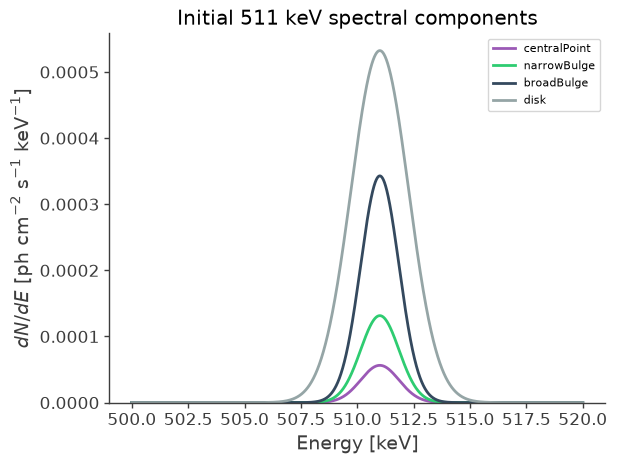

In [29]:


fig, ax = plt.subplots()

# Evaluate and plot the initial spectrum of each source component.
for name, source in zip(component_names, source_components):
    differential_flux = source.spectrum.main.shape(energy)
    ax.plot(
        energy,
        differential_flux,
        label=name,
    )

ax.set_xlabel("Energy [keV]", fontsize=14)
ax.set_ylabel(
    r"$dN/dE$ [ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$]",
    fontsize=14,
)
ax.set_title("Initial 511 keV spectral components")
ax.set_ylim(bottom=0)
ax.legend()

plt.show()

In [30]:
# Define healpix map matching the detector response:
nside_model = 2**4
scheme='ring'
is_nested = (scheme == 'nested')
coordsys='G'

mBroadBulge = HealpixMap(nside = nside_model, scheme = scheme, dtype = float,coordsys=coordsys)
mNarrowBulge = HealpixMap(nside = nside_model, scheme = scheme, dtype = float,coordsys=coordsys)
mPointBulge = HealpixMap(nside = nside_model, scheme = scheme, dtype = float,coordsys=coordsys)
mDisk = HealpixMap(nside = nside_model, scheme=scheme, dtype = float,coordsys=coordsys)

In [31]:
coords = mDisk.pix2skycoord(range(mDisk.npix)) # common among all the galactic maps...

pix_area = mBroadBulge.pixarea().value # common among all the galactic maps with the same pixelization

In [32]:
# Fill skymap with values from extended source: 
mNarrowBulge[:] = narrow_bulge_source.spatial_shape(
    coords.l.deg, 
    coords.b.deg
    )

mBroadBulge[:] = broad_bulge_source.spatial_shape(
    coords.l.deg, 
    coords.b.deg
    )

mBulge = mBroadBulge + mNarrowBulge

mDisk[:] = disk_source.spatial_shape(
    coords.l.deg, 
    coords.b.deg
    )

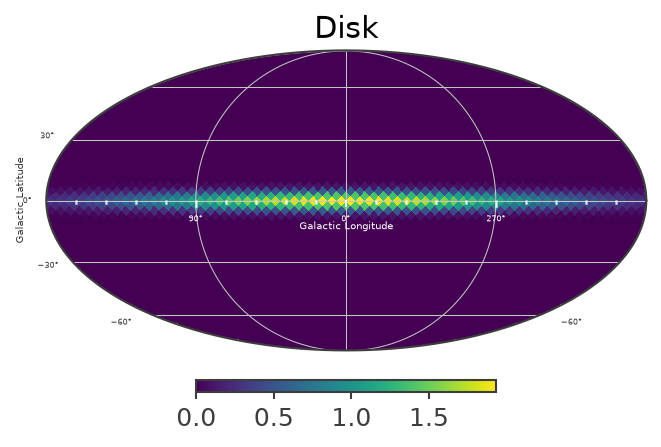

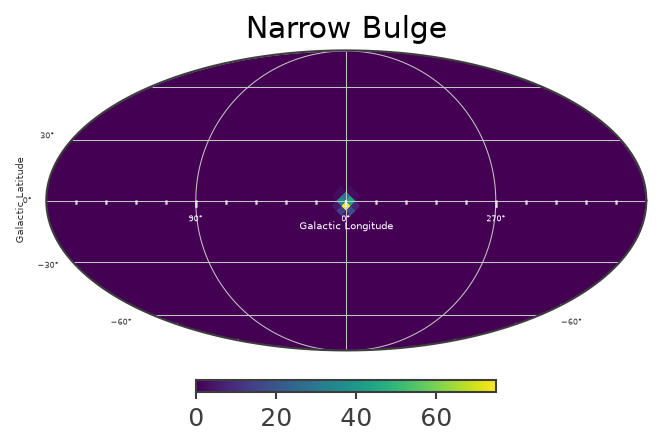

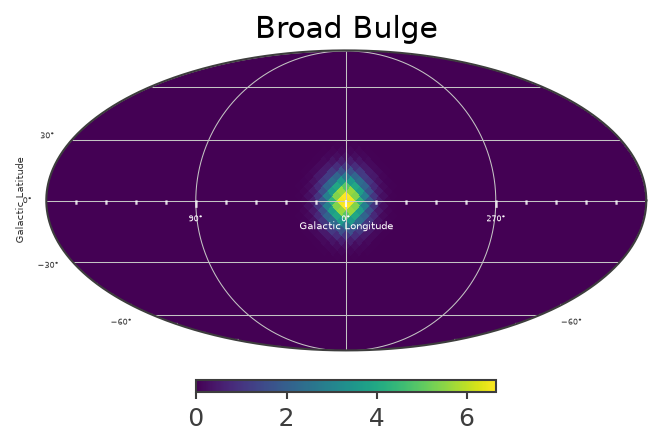

In [33]:
List_of_Maps = [mDisk,mNarrowBulge,mBroadBulge]
List_of_Names = ["Disk","Narrow Bulge","Broad Bulge", ]

for n, m in zip(List_of_Names,List_of_Maps):
    plot,ax = m.plot(ax_kw={"coord":"G"})
    ax.grid();
    lon = ax.coords['glon']
    lat = ax.coords['glat']
    lon.set_axislabel('Galactic Longitude',color='white',fontsize=5)
    lat.set_axislabel('Galactic Latitude',fontsize=5)
    lon.display_minor_ticks(True)
    lat.display_minor_ticks(True)
    lon.set_ticks_visible(True)
    lon.set_ticklabel_visible(True)
    lon.set_ticks(color='white',alpha=0.6)
    lat.set_ticks(color='white',alpha=0.6)
    lon.set_ticklabel(color='white',fontsize=4)
    lat.set_ticklabel(fontsize=4)
    lat.set_ticks_visible(True)
    lat.set_ticklabel_visible(True)
    ax.set_title(n)

## Prepare the COSI likelihood

The likelihood must compare the observed CDS counts with source and background counts predicted in exactly the same `(Em, Phi, PsiChi)` bins. This section therefore wraps the combined fourteen-week observation, loads the DC4 orientation and response products, constructs the source-response operators, and gives the background normalization its own free nuisance parameter.

### Wrap the observed CDS counts

`EmCDSBinnedData` is the likelihood-facing wrapper around the already combined observation. It does not generate or alter events; it validates that the histogram contains the three required CDS axes.

In [34]:
# Wrap the combined observed counts for the binned likelihood.
data_511 = EmCDSBinnedData(
    observed_511_histogram,
)

print("Likelihood data axes:", data_511.axes.labels)
print("Likelihood data shape:", data_511.data.shape)

Likelihood data axes: ['Em' 'Phi' 'PsiChi']
Likelihood data shape: (1, 60, 3072)


### Load the observing history and response products

The orientation history supplies the exposure and pointing as a function of time. The precomputed extended-source response is used for the two bulges and disk, while the full detector response is used to calculate the central point-source response. Opening the extended response can take time and substantial memory because its uncompressed file is several gigabytes.

In [35]:
# Load the DC4 spacecraft orientation and livetime history.
spacecraft_history = SpacecraftHistory.open(
    paths.data_ori_path,
)

# Load the precomputed response for extended Galactic sources.
extended_response_511 = ExtendedSourceResponse.open(
    paths.data_ext_response511_path,
)

# Load the full detector response for the central point source.
full_response_511 = FullDetectorResponse.open(
    paths.data_response511_path,
)

# Match the full detector response to the observed CDS binning.
instrument_response_511 = BinnedInstrumentResponse(
    full_response_511,
    data_511,
)

In [36]:
# Confirm that both response paths predict the observed CDS bins.
if extended_response_511.axes[2:] != data_511.axes:
    raise ValueError(
        "Extended response and observed data use incompatible CDS axes."
    )

if instrument_response_511.axes != data_511.axes:
    raise ValueError(
        "Point-source response and observed data use incompatible CDS axes."
    )

print("Response and observed CDS axes are compatible.")

Response and observed CDS axes are compatible.


### Construct the free-normalization background

The simulated background histogram supplies the fixed CDS shape. `FreeNormBinnedBackground` normalizes that shape internally and converts its normalization into a rate parameter. A strictly positive numerical floor prevents zero expected counts from producing an undefined Poisson logarithm. The starting rate is derived from the simulated background total and the observation livetime; it is not fixed during the fit.

In [37]:
# Work on a copy because the background class normalizes in place.
background_distribution = {
    "background": simulated_background_511_histogram.copy(),
}

# Prevent exactly zero expectations in empty background bins.
for background_component in background_distribution.values():
    background_component += sys.float_info.min

background_model_511 = FreeNormBinnedBackground(
    background_distribution,
    sc_history=spacecraft_history,
    copy=False,
)

# Use the simulated background count total only as the optimizer start.
initial_background_rate = (
    simulated_background_count_total
    / spacecraft_history.cumulative_livetime()
).to(u.Hz)
background_model_511.set_norm({
    "background": initial_background_rate,
})

if background_model_511.axes != data_511.axes:
    raise ValueError(
        "Background model and observed data use incompatible CDS axes."
    )

print("Initial background rate:", background_model_511.norm)

Initial background rate: 0.20897841875324394 Hz


### Build the response-folded source prediction

The two source-response adapters convert the point and extended sky components into predicted counts. `BinnedThreeMLModelFolding` then sums the prediction from every source in the astromodels model.

In [38]:
# Configure the precomputed response used by extended sources.
extended_source_response_511 = BinnedThreeMLExtendedSourceResponse(
    data=data_511,
    precomputed_psr=extended_response_511,
)

# Configure the orientation-dependent response used by the point source.
point_source_response_511 = BinnedThreeMLPointSourceResponse(
    data=data_511,
    instrument_response=instrument_response_511,
    sc_history=spacecraft_history,
    energy_axis=extended_response_511.axes["Ei"],
    polarization_axis=(
        extended_response_511.axes["Pol"]
        if "Pol" in extended_response_511.axes.labels
        else None
    ),
    nside=2 * data_511.axes["PsiChi"].nside,
)

# Sum the response-folded prediction from every source component.
model_folding_511 = BinnedThreeMLModelFolding(
    data=data_511,
    point_source_response=point_source_response_511,
    extended_source_response=extended_source_response_511,
)

### Assemble the model and likelihood

The total sky model contains the central point source, both bulges, and the disk. The binned Poisson likelihood compares their response-folded prediction plus the free-normalization background against the observed counts. Constructing these objects does not yet optimize any parameter.

In [39]:
# Combine the four sky components into one astromodels model.
source_model_511 = Model(
    central_point_source,
    narrow_bulge_source,
    broad_bulge_source,
    disk_source,
)

# Define the Poisson comparison of observed and expected CDS counts.
poisson_likelihood_511 = PoissonLikelihood(
    data=data_511,
    response=model_folding_511,
    bkg=background_model_511,
)

# Expose the COSI likelihood and background parameter to 3ML.
cosi_plugin_511 = ThreeMLPluginInterface(
    name="cosi_511",
    likelihood=poisson_likelihood_511,
    response=model_folding_511,
    bkg=background_model_511,
)
cosi_plugin_511.bkg_parameter["background"].min_value = 0.0

plugins_511 = DataList(cosi_plugin_511)
likelihood_511 = JointLikelihood(
    source_model_511,
    plugins_511,
    verbose=False,
)

source_model_511.display(complete=True)

Model summary:
==============

                  N
Point sources     1
Extended sources  3
Particle sources  0

Free parameters (6):
--------------------

                                          value min_value max_value      unit
centralPoint.spectrum.main.Gaussian.F   0.00012       0.0      None  s-1 cm-2
narrowBulge.spectrum.main.Gaussian.F    0.00028       0.0      None  s-1 cm-2
broadBulge.spectrum.main.Gaussian.F     0.00073       0.0      None  s-1 cm-2
disk.Asymm_Gaussian_on_sphere.e        0.999444       0.0       1.0          
disk.spectrum.main.Gaussian.F            0.0017       0.0      None  s-1 cm-2
background                             0.208978       0.0      None        Hz

Fixed parameters (28):
---------------------

                                               value min_value max_value unit
centralPoint.position.ra                  266.404988       0.0     360.0  deg
centralPoint.position.dec                 -28.936178     -90.0      90.0  deg
centralPoint.spectrum.main.Gaussian.mu         511.0      None      None  keV
centralPoint...sigma                        0.849322       0.0      None  keV
centralPoint...degree                            0.0       0.0     100.0     
centralPoint...angle                             0.0       0.0     180.0  deg
narrowBulge.Gaussian_on_sphere.lon0           359.75       0.0     360.0  deg
narrowBulge.Gaussian_on_sphere.lat0            -1.25     -90.0      90.0  deg
narrowBulge.Gaussian_on_sphere.sigma             2.5       0.0      20.0  deg
narrowBulge.spectrum.main.Gaussian.mu          511.0      None      None  keV
narrowBulge.spectrum.main.Gaussian.sigma    0.849322       0.0      None  keV
narrowBulge...degree                             0.0       0.0     100.0     
narrowBulge...angle                              0.0       0.0     180.0  deg
broadBulge.Gaussian_on_sphere.lon0               0.0       0.0     360.0  deg
broadBulge.Gaussian_on_sphere.lat0               0.0     -90.0      90.0  deg
broadBulge.Gaussian_on_sphere.sigma              8.7       0.0      20.0  deg
broadBulge.spectrum.main.Gaussian.mu           511.0      None      None  keV
broadBulge.spectrum.main.Gaussian.sigma     0.849322       0.0      None  keV
broadBulge...degree                              0.0       0.0     100.0     
broadBulge...angle                               0.0       0.0     180.0  deg
disk.Asymm_Gaussian_on_sphere.lon0               0.0       0.0     360.0  deg
disk.Asymm_Gaussian_on_sphere.lat0               0.0     -90.0      90.0  deg
disk.Asymm_Gaussian_on_sphere.a                 90.0       0.0      90.0  deg
disk.Asymm_Gaussian_on_sphere.theta              0.0     -90.0      90.0  deg
disk.spectrum.main.Gaussian.mu                 511.0      None      None  keV
disk.spectrum.main.Gaussian.sigma           1.273983       0.0      None  keV
disk.spectrum.main.polarization.degree           0.0       0.0     100.0     
disk.spectrum.main.polarization.angle            0.0       0.0     180.0  deg

Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

## Fit the model

This is the first cell that actually optimizes the free source parameters and background normalization. Response folding can make it computationally expensive, especially for the central point source.

In [40]:
# Optimize all free source and background parameters.
likelihood_511.fit()

# Store and display the fitted parameter values and uncertainties.
fit_results_511 = likelihood_511.results
fit_results_511.display()

The current value of parameter F is very close to its lower bound when starting the fit. Fixing it



WARNING UserWarning: 48.4% of samples have been thrown away because they failed the constraints on the parameters. This result might not be suitable for error propagation. Enlarge the boundaries until you lose less than 1% ofthe samples.
Discarded samples in excluded parameter space (2421 samples):
  F: mean=0.001482, std=4.401e-05, bounds=[0, inf]
  F: mean=-2.793e-07, std=2.08e-07, bounds=[0, inf]
  F: mean=0.0002386, std=6.186e-05, bounds=[0, inf]
  e: mean=0.9972, std=0.0004691, bounds=[0, 1]
  F: mean=0.003389, std=7.268e-05, bounds=[0, inf]
  background: mean=0.2117, std=0.0003834, bounds=[0, inf]



Best fit values:

,result,unit
parameter,,
centralPoint.spectrum.main.Gaussian.F,(1.48 +/- 0.04) x 10^-3,1 / (s cm2)
narrowBulge.spectrum.main.Gaussian.F,(0.0 +/- 3.5) x 10^-7,1 / (s cm2)
broadBulge.spectrum.main.Gaussian.F,(2.4 +/- 0.6) x 10^-4,1 / (s cm2)
disk.Asymm_Gaussian_on_sphere.e,(9.972 +/- 0.005) x 10^-1,
disk.spectrum.main.Gaussian.F,(3.39 +/- 0.07) x 10^-3,1 / (s cm2)
background,(2.117 +/- 0.004) x 10^-1,Hz


Correlation matrix:

...

1.00,-0.04,-0.85,-0.22,0.20,-0.06
-0.04,1.00,-0.01,-0.00,0.00,-0.00
-0.85,-0.01,1.00,0.23,-0.42,0.09
-0.22,-0.00,0.23,1.00,-0.46,0.37
0.20,0.00,-0.42,-0.46,1.00,-0.78
-0.06,-0.00,0.09,0.37,-0.78,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_511,-2273337.2858025837
total,-2273337.2858025837


Values of statistical measures:

,statistical measures
AIC,-4546662.571149421
BIC,-4546601.825033229


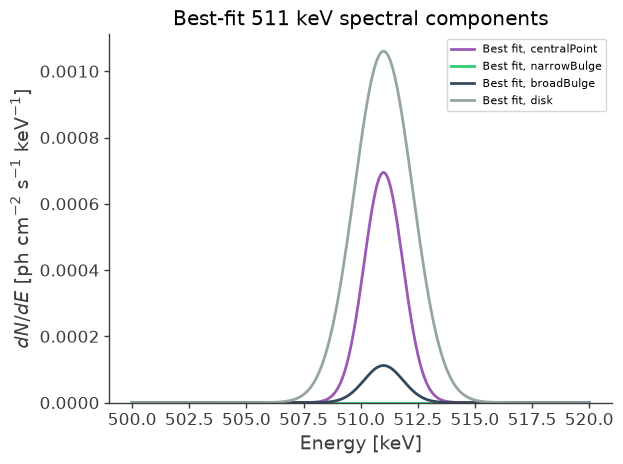

In [41]:
# Define the energy grid used to display the fitted spectra.
energy = np.linspace(500.0, 520.0, 201) * u.keV

best_fit_fluxes = {}

# Evaluate each source spectrum using its fitted parameters.
for component_name in component_names:
    fitted_source = fit_results_511.optimized_model[component_name]
    best_fit_fluxes[component_name] = (
        fitted_source.spectrum.main.shape(energy)
    )

fig, ax = plt.subplots()

# Plot the fitted spectrum of every source component.
for component_name in component_names:
    ax.plot(
        energy,
        best_fit_fluxes[component_name],
        label=f"Best fit, {component_name}",
    )

ax.set_xlabel("Energy [keV]", fontsize=14)
ax.set_ylabel(
    r"$dN/dE$ [ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$]",
    fontsize=14,
)
ax.set_title("Best-fit 511 keV spectral components")
ax.set_ylim(bottom=0)
ax.legend()

plt.tight_layout()

### Convert the fitted disk ellipticity to a latitude scale

For this spatial model, the latitude scale is $b = a\sqrt{1-e^2}$. The fit varies $e$ while $a=90^\circ$ remains fixed. The parameter samples stored by 3ML are transformed directly so the nonlinear uncertainty in $b$ is retained.

In [42]:
# Retrieve the fitted ellipticity and its covariance-derived samples.
disk_e_variates = fit_results_511.get_variates(
    "disk.Asymm_Gaussian_on_sphere.e",
)
disk_e_best = disk_e_variates.value
disk_e_samples = np.asarray(disk_e_variates.samples, dtype=float)

# Read the fixed longitude scale from the optimized disk model.
disk_a_deg = (
    fit_results_511.optimized_model["disk"]
    .spatial_shape.a.value
)

# Keep only physically valid ellipticity samples before transformation.
valid_e_samples = (
    np.isfinite(disk_e_samples)
    & (disk_e_samples >= 0.0)
    & (disk_e_samples <= 1.0)
)
disk_e_samples = disk_e_samples[valid_e_samples]

if disk_e_samples.size == 0:
    raise RuntimeError("No valid disk ellipticity samples are available.")

# Transform the best fit and every valid sample to the latitude scale.
disk_b_best_deg = disk_a_deg * np.sqrt(1.0 - disk_e_best**2)
disk_b_samples_deg = disk_a_deg * np.sqrt(
    1.0 - disk_e_samples**2
)

disk_e_low, disk_e_high = np.quantile(
    disk_e_samples,
    [0.16, 0.84],
)
disk_b_low_deg, disk_b_high_deg = np.quantile(
    disk_b_samples_deg,
    [0.16, 0.84],
)

print(
    "Fitted disk ellipticity: "
    f"e = {disk_e_best:.6f} "
    f"(68% interval: {disk_e_low:.6f}, {disk_e_high:.6f})"
)
print(
    "Fitted disk latitude scale: "
    f"b = {disk_b_best_deg:.3f} deg "
    f"(68% interval: {disk_b_low_deg:.3f}, "
    f"{disk_b_high_deg:.3f} deg)"
)

Fitted disk ellipticity: e = 0.997191 (68% interval: 0.996746, 0.997643)
Fitted disk latitude scale: b = 6.741 deg (68% interval: 6.176, 7.254 deg)


### Check the fitted counts in Compton Data Space

The following diagnostic compares the observed counts with the fitted source-plus-background expectation after projecting onto $\Phi$. Its Pearson residuals test the fit in that projection only; they are not a complete validation of the full three-dimensional CDS model.

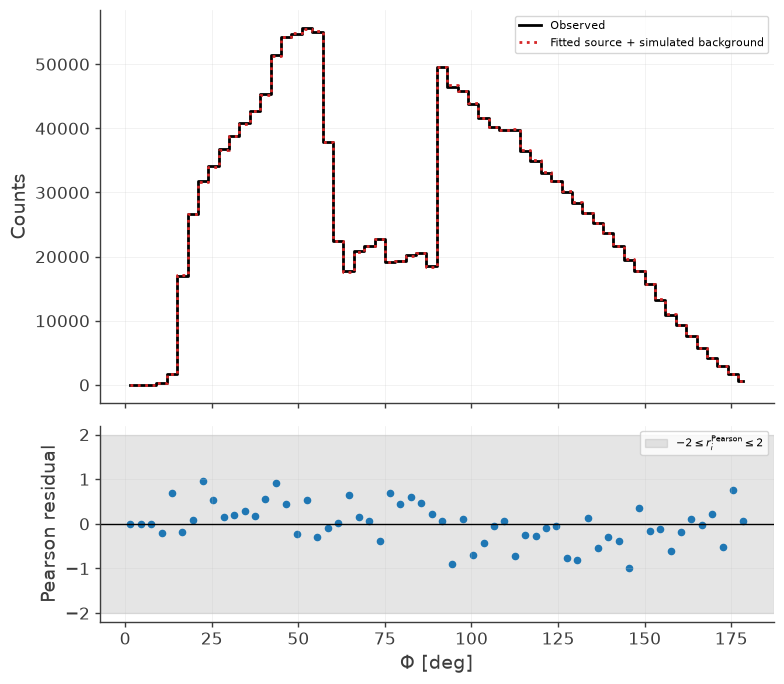

In [43]:
# Ensure the response uses the optimized source model.
model_folding_511.set_model(fit_results_511.optimized_model)

# Build the fitted source-plus-background expectation in CDS.
fitted_source_511 = model_folding_511.expectation(copy=True)
fitted_background_511 = background_model_511.expectation(copy=True)
fitted_total_511 = fitted_source_511 + fitted_background_511

observed_counts_511 = np.asarray(
    data_511.data.contents,
    dtype=float,
)
expected_counts_511 = np.asarray(
    fitted_total_511.contents,
    dtype=float,
)

# Sum every axis except Phi for a one-dimensional diagnostic.
phi_axis_index = list(data_511.axes.labels).index("Phi")
projection_axes = tuple(
    axis_index
    for axis_index in range(observed_counts_511.ndim)
    if axis_index != phi_axis_index
)
observed_phi_511 = observed_counts_511.sum(axis=projection_axes)
expected_phi_511 = expected_counts_511.sum(axis=projection_axes)
phi_centers_511 = data_511.axes["Phi"].centers

# Pearson residuals use the fitted expectation as the Poisson variance.
valid_phi_bins = expected_phi_511 > 0.0
pearson_phi_511 = np.full_like(expected_phi_511, np.nan)
pearson_phi_511[valid_phi_bins] = (
    observed_phi_511[valid_phi_bins]
    - expected_phi_511[valid_phi_bins]
) / np.sqrt(expected_phi_511[valid_phi_bins])

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

axes[0].step(
    phi_centers_511,
    observed_phi_511,
    where="mid",
    color="black",
    label="Observed",
)
axes[0].step(
    phi_centers_511,
    expected_phi_511,
    where="mid",
    color="tab:red",
    linestyle=":",
    label="Fitted source + simulated background",
)
axes[0].set_ylabel("Counts")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhspan(
    -2.0,
    2.0,
    color="gray",
    alpha=0.2,
    label=r"$-2 \leq r_i^{\mathrm{Pearson}} \leq 2$",
)
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].scatter(
    phi_centers_511,
    pearson_phi_511,
    s=20,
    color="tab:blue",
)
axes[1].set_xlabel(r"$\Phi$ [deg]")
axes[1].set_ylabel("Pearson residual")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Status of the $^{26}$Al comparison

The repository documentation lists the $^{26}$  Al response and simulated event products, but those files are not present in the local data directories. The 511 keV disk scale above is therefore ready for comparison, while the numerical $^{26}$ Al comparison must wait until an $^{26}$ Al fit result or spatial template is available.